<a href="https://colab.research.google.com/github/VisithraRavichandran/HALIFA/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [ ]:
iris=load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [ ]:
from sklearn import svm
X=iris.data[:,:2]
y=iris.target

In [ ]:
#SVM Configuration parameters
C=1.0#regularization parameter

In [ ]:
#Linear Kernel
svc=svm.SVC(kernel='linear',C=C).fit(X,y)

In [ ]:
svc

SVC(kernel='linear')

In [ ]:
rbf_svc=svm.SVC(kernel='rbf',gamma=0.7,C=C).fit(X,y)
rbf_svc

SVC(gamma=0.7)

In [ ]:
#SVC with poly
poly_svc=svm.SVC(kernel='poly',degree=3,C=C).fit(X,y)
poly_svc

SVC(kernel='poly')

In [ ]:
#Split the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#SVC linear
lin_svc=svm.LinearSVC(C=C).fit(X,y)

In [ ]:
#setting up the grid
h=0.02
x_min=X[:,0].min()-1
x_max=X[:,0].max()+1
y_min=X[:,1].min()-1
y_max=X[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

In [ ]:
titles=['SVC with linear Kernel','SVC with RBF Kernel','SVC with Poly Kernel']

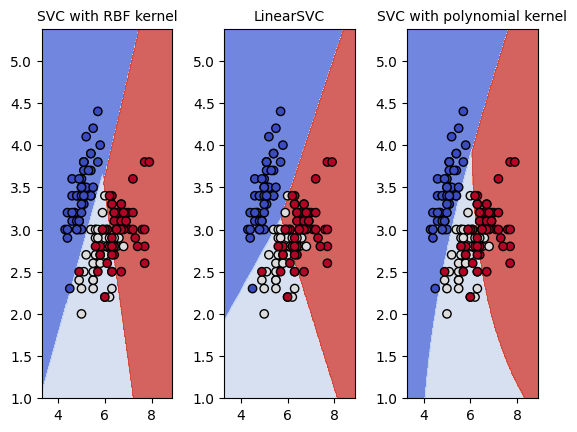

In [ ]:
for i, clf in enumerate((svc, lin_svc, poly_svc)):
    plt.subplot(1, 3, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    # 1. Predict the model's decision across the meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 2. DRAW THE BOUNDARIES (This fills the blank background with color)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # 3. DRAW THE DATA POINTS (This puts your points on top)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

    # 4. Optional: Add a title to identify each plot
    titles = ('SVC with RBF kernel', 'LinearSVC', 'SVC with polynomial kernel')
    plt.title(titles[i], fontsize=10)

# Finally, display the finished plots
plt.show()